<a href="https://colab.research.google.com/github/Aswini-J/Exp3-Sobel-edge-detection-filter-using-CUDA-to-enhance-the-performance-of-image-processing-tasks./blob/main/Sobel_edge_detection_image_processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
!pip install git+https://github.com/andreinechaev/nvcc4jupyter.git
%load_ext nvcc4jupyter

  Cloning https://github.com/andreinechaev/nvcc4jupyter.git to /tmp/pip-req-build-8e5gfupz
  Running command git clone --filter=blob:none --quiet https://github.com/andreinechaev/nvcc4jupyter.git /tmp/pip-req-build-8e5gfupz
  Resolved https://github.com/andreinechaev/nvcc4jupyter.git to commit 28f872a2f99a1b201bcd0db14fdbc5a496b9bfd7
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
The nvcc4jupyter extension is already loaded. To reload it, use:
  %reload_ext nvcc4jupyter


In [17]:
!nvcc --version


nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0


In [18]:
%load_ext nvcc4jupyter

The nvcc4jupyter extension is already loaded. To reload it, use:
  %reload_ext nvcc4jupyter


In [19]:
from pathlib import Path

file_path = Path('/content/WhiteHouse.jpg')
if file_path.exists():
    print("File exists!")
else:
    print("File does not exist!")


File exists!


In [20]:
import os
print("Current Working Directory:", os.getcwd())

Current Working Directory: /content


In [21]:
from google.colab import files
uploaded = files.upload()

KeyboardInterrupt: 

In [22]:
from pathlib import Path

# Assuming the file is in the same directory as the notebook
file_path = Path('/content/WhiteHouse.jpg')
if file_path.exists():
    print("File exists!")
else:
    print("File does not exist!")


File exists!


In [ ]:
pwd


In [23]:
ls /content/images.jpeg

ls: cannot access '/content/images.jpeg': No such file or directory


In [24]:
#ls -l /content/images.jpeg
import cv2
image = cv2.imread('/content/WhiteHouse.jpg')
if image is None:
    print("Error: Image not found or unable to read the image.")
else:
    print("Image read successfully.")


Image read successfully.


In [32]:
%%writefile sobelEdgeDetectionFilter.cu
#include <stdio.h>
#include <stdlib.h>
#include <math.h>
#include <cuda_runtime.h>
#include <opencv2/opencv.hpp>

using namespace cv;

__constant__ int Gx[3][3] = {
    {-1, 0, 1},
    {-2, 0, 2},
    {-1, 0, 1}
};

__constant__ int Gy[3][3] = {
    {1, 2, 1},
    {0, 0, 0},
    {-1, -2, -1}
};

__global__ void sobelFilter(unsigned char *srcImage,
                            unsigned char *dstImage,
                            unsigned int width,
                            unsigned int height) {

    int x = blockIdx.x * blockDim.x + threadIdx.x;
    int y = blockIdx.y * blockDim.y + threadIdx.y;

    if (x >= 1 && x < width - 1 &&
        y >= 1 && y < height - 1) {

        int sumX = 0;
        int sumY = 0;

        for (int i = -1; i <= 1; i++) {
            for (int j = -1; j <= 1; j++) {

                unsigned char pixel =
                    srcImage[(y + i) * width + (x + j)];

                sumX += pixel * Gx[i + 1][j + 1];
                sumY += pixel * Gy[i + 1][j + 1];
            }
        }

        float magnitude =
            sqrtf((float)(sumX * sumX + sumY * sumY));

        magnitude = min(max((int)magnitude, 0), 255);

        dstImage[y * width + x] =
            (unsigned char)magnitude;
    }

    else if (x < width && y < height) {

        dstImage[y * width + x] = 0;
    }
}

void checkCudaErrors(cudaError_t r) {
    if (r != cudaSuccess) {
        fprintf(stderr, "CUDA Error: %s\n", cudaGetErrorString(r));
        exit(EXIT_FAILURE);
    }
}

int main() {
    // Read input image
    Mat image = imread("/content/WhiteHouse.jpg", IMREAD_COLOR);

    if (image.empty()) {
        printf("Error: Image not found.\n");
        return -1;
    }

    // Convert to grayscale
    Mat gray_image;
    cvtColor(image, gray_image, COLOR_BGR2GRAY);

    int width = gray_image.cols;
    int height = gray_image.rows;
    size_t imageSize = width * height * sizeof(unsigned char);

    // Allocate host memory for output image
    unsigned char *h_outputImage = (unsigned char *)malloc(imageSize);
    if (h_outputImage == nullptr) {
        fprintf(stderr, "Failed to allocate host memory\n");
        return -1;
    }

    // Allocate device memory
    unsigned char *d_inputImage, *d_outputImage;
    checkCudaErrors(cudaMalloc(&d_inputImage, imageSize));
    checkCudaErrors(cudaMalloc(&d_outputImage, imageSize));
    checkCudaErrors(cudaMemcpy(d_inputImage, gray_image.data, imageSize, cudaMemcpyHostToDevice));

    // Define CUDA events for timing
    cudaEvent_t start, stop;
    cudaEventCreate(&start);
    cudaEventCreate(&stop);

    // Launch kernel
    dim3 blockSize(16, 16);
    dim3 gridSize(ceil(width / 16.0), ceil(height / 16.0));

    cudaEventRecord(start);
    sobelFilter<<<gridSize, blockSize>>>(d_inputImage, d_outputImage, width, height);
    cudaEventRecord(stop);

    // Synchronize events
    cudaEventSynchronize(stop);

    // Calculate elapsed time
    float milliseconds = 0;
    cudaEventElapsedTime(&milliseconds, start, stop);

    // Copy result back to host
    checkCudaErrors(cudaMemcpy(h_outputImage, d_outputImage, imageSize, cudaMemcpyDeviceToHost));

    // Write output image
    Mat outputImage(height, width, CV_8UC1, h_outputImage);
    imwrite("output_sobel.jpeg", outputImage);

    // Free memory
    free(h_outputImage);
    cudaFree(d_inputImage);
    cudaFree(d_outputImage);

    // Destroy CUDA events
    cudaEventDestroy(start);
    cudaEventDestroy(stop);

    // Print elapsed time
    printf("Total time taken: %f milliseconds\n", milliseconds);

    return 0;
}

Overwriting sobelEdgeDetectionFilter.cu


In [28]:
print('Installing libopencv-dev...')
!apt-get update && apt-get install -y libopencv-dev

Installing libopencv-dev...
Hit:1 https://cli.github.com/packages stable InRelease
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:5 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [95.6 kB]
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:7 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:8 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,646 kB]
Get:9 http://security.ubuntu.com/ubuntu jammy-security/multiverse amd64 Packages [77.8 kB]
Get:10 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [7,070 kB]
Get:11 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,295 kB

In [33]:
!nvcc -o sobelEdgeDetectionFilter sobelEdgeDetectionFilter.cu `pkg-config --cflags --libs opencv4`

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
/usr/include/opencv4/opencv2/stitching/detail/warpers.hpp(235): warning #611-D: overloaded virtual function "cv::detail::PlaneWarper::buildMaps" is only partially overridden in class "cv::detail::AffineWarper"
  class AffineWarper : public PlaneWarper
        ^

Remark: The warnings can be suppressed with "-diag-suppress <warning-number>"

/usr/include/opencv4/opencv2/stitching/detail/warpers.hpp(235): warning #611-D: overloaded virtual function "cv::detail::PlaneWarper::warp" is only partially overridden in class "cv::detail::AffineWarper"
  class AffineWarper : public PlaneWarper
        ^

/usr/include/opencv4/opencv2/stitching/detail/blenders.hpp(100): warning #611-D: overloaded virtual function "cv::detail::Blender::prepare" is only partially overridden in class "cv::detail::FeatherBlender"
  clas

In [34]:
!./sobelEdgeDetectionFilter

Total time taken: 0.292288 milliseconds


## Resources

In [27]:
!./sobelEdgeDetectionFilter

/bin/bash: line 1: ./sobelEdgeDetectionFilter: No such file or directory


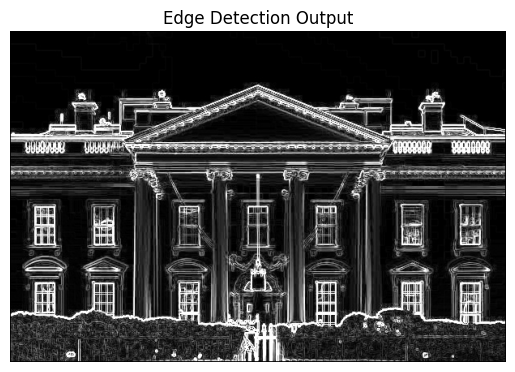

In [35]:
import cv2
from matplotlib import pyplot as plt

# Read and display the output image
output_image_path = '/content/output_sobel.jpeg'
output_image = cv2.imread(output_image_path, cv2.IMREAD_GRAYSCALE)  # Use IMREAD_GRAYSCALE if it's a single-channel image

# Display the image
plt.imshow(output_image, cmap='gray')
plt.title('Edge Detection Output')
plt.axis('off')  # Hide the axes
plt.show()